In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
import h5py
import xml.etree.ElementTree as ET
import os

# Paths (adjust to your actual locations)
SOLID_DIR = Path("/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/solid/v18_reissner_mindlin_plate/")
FLUID_DIR = Path("/media/dysco/New Volume1/Neeraj/varflexi solver/temp/")
COUPLING_DIR = Path("/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/coupling/")
FIG_DIR = Path("/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/check_plots/heaving_validation/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
span = 0.30
chord = 0.10
Uinf = 4.43
kG = 1.82
freq = kG * Uinf / (np.pi * chord)
omega = 2 * np.pi * freq
print("Frequency =", freq)

Frequency = 25.664052883454307


In [3]:
import h5py
import xml.etree.ElementTree as ET
import numpy as np
import re

def read_solid_xdmf(xdmf_path):
    """
    Parse XDMF file and read displacement data from HDF5.
    Returns times, tip_w, coords.
    """
    if not xdmf_path.exists():
        raise FileNotFoundError(f"XDMF file not found: {xdmf_path}")
    
    # Parse XDMF XML
    tree = ET.parse(str(xdmf_path))
    root = tree.getroot()
    
    # Find TimeSeries Grid
    time_series_grid = root.find(".//Grid[@Name='TimeSeries']")
    if time_series_grid is None:
        raise ValueError("No TimeSeries Grid found.")
    
    child_grids = time_series_grid.findall("Grid")
    if not child_grids:
        raise ValueError("No Grid children found in TimeSeries.")
    
    # First grid contains geometry
    first_grid = child_grids[0]
    geometry = first_grid.find(".//Geometry")
    if geometry is None:
        raise ValueError("No Geometry element found in first grid.")
    coord_item = geometry.find(".//DataItem")
    if coord_item is None:
        raise ValueError("No DataItem for coordinates.")
    coord_dataset_raw = coord_item.text.strip()   # e.g., "elastodynamics-results.h5:/Mesh/0/mesh/geometry"
    
    # Strip the file name prefix (e.g., "elastodynamics-results.h5:")
    def strip_h5_prefix(path):
        if '.h5:' in path:
            return path.split(':', 1)[1]
        return path
    
    coord_dataset = strip_h5_prefix(coord_dataset_raw)
    
    h5_path = xdmf_path.with_suffix(".h5")
    if not h5_path.exists():
        raise FileNotFoundError(f"HDF5 file not found: {h5_path}")
    
    with h5py.File(h5_path, 'r') as f:
        # Debug: print top-level keys
        print("Top-level keys in HDF5:", list(f.keys()))
        
        # Get coordinates
        try:
            coords = f[coord_dataset][:]
        except KeyError:
            print(f"Could not find dataset '{coord_dataset}'. Searching for alternative...")
            # Recursively search for a dataset with 'geometry' or 'coord' in name
            found = None
            def find_coord(name, obj):
                if isinstance(obj, h5py.Dataset):
                    if 'geometry' in name.lower() or 'coord' in name.lower():
                        return name
                return None
            for name, obj in f.items():
                if isinstance(obj, h5py.Dataset) and ('geometry' in name.lower() or 'coord' in name.lower()):
                    found = name
                    break
                elif isinstance(obj, h5py.Group):
                    for subname in obj:
                        full = name + '/' + subname
                        if 'geometry' in full.lower() or 'coord' in full.lower():
                            found = full
                            break
                    if found:
                        break
            if found is None:
                raise RuntimeError("Could not find any coordinate dataset in HDF5 file.")
            print(f"Using alternative dataset: {found}")
            coords = f[found][:]
            coord_dataset = found
        
        if coords.shape[1] == 2:
            coords = np.hstack([coords, np.zeros((coords.shape[0], 1))])
        
        # Tip coordinates
        tip_coord = np.array([0.075, 0.30])
        dist = np.linalg.norm(coords[:, :2] - tip_coord, axis=1)
        tip_idx = np.argmin(dist)
        print(f"Tip node index: {tip_idx}")
        
        times = []
        tip_w = []
        
        # Get all displacement dataset paths under VisualisationVector
        # We'll store a list of paths for the fallback
        disp_paths = []
        if 'VisualisationVector' in f:
            group = f['VisualisationVector']
            # Sort by numeric index
            for key in sorted(group.keys(), key=lambda x: int(x) if x.isdigit() else -1):
                disp_paths.append('VisualisationVector/' + key)
        else:
            # Search recursively for any dataset that looks like a displacement vector (dimensions match nodes × 5)
            def find_disp(name, obj):
                if isinstance(obj, h5py.Dataset) and obj.ndim == 2 and obj.shape[1] == 5:
                    return name
                return None
            for name, obj in f.items():
                if isinstance(obj, h5py.Dataset) and obj.ndim == 2 and obj.shape[1] == 5:
                    disp_paths.append(name)
                elif isinstance(obj, h5py.Group):
                    for subname in obj:
                        sub_obj = obj[subname]
                        if isinstance(sub_obj, h5py.Dataset) and sub_obj.ndim == 2 and sub_obj.shape[1] == 5:
                            disp_paths.append(name + '/' + subname)
            # Sort if possible
            disp_paths.sort()
        
        print(f"Found {len(disp_paths)} displacement datasets: {disp_paths[:5]}...")
        
        # Iterate over time grids
        for i, grid in enumerate(child_grids):
            # Time
            time_elem = grid.find("Time")
            t = float(time_elem.get("Value")) if time_elem is not None else float(i)
            times.append(t)
            
            # Attribute
            attr = grid.find(".//Attribute[@Name='PlateState']")
            if attr is None:
                raise ValueError(f"Attribute 'PlateState' not found in grid {i}.")
            disp_item = attr.find(".//DataItem")
            if disp_item is None:
                raise ValueError(f"No DataItem in Attribute for grid {i}.")
            disp_dataset_raw = disp_item.text.strip()
            disp_dataset = strip_h5_prefix(disp_dataset_raw)
            
            # Try to read displacement
            try:
                disp_data = f[disp_dataset][:]
            except KeyError:
                # Fallback: use the i-th dataset from disp_paths
                if i < len(disp_paths):
                    disp_dataset = disp_paths[i]
                    print(f"Using fallback displacement dataset: {disp_dataset}")
                    disp_data = f[disp_dataset][:]
                else:
                    raise RuntimeError(f"Not enough displacement datasets for grid {i}.")
            
            # Extract w component (index 2)
            w_val = disp_data[tip_idx, 2]
            tip_w.append(w_val)
    
    times = np.array(times)
    tip_w = np.array(tip_w)
    return times, tip_w, coords


xdmf_path = SOLID_DIR / "elastodynamics-results.xdmf"
try:
    times_raw, tip_w, coords = read_solid_xdmf(xdmf_path)
except Exception as e:
    print(f"Error reading XDMF: {e}")
    # Fallback to a pre‑saved CSV if available
    csv_path = SOLID_DIR / "recovered_tip_displacement.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        times_raw = df["time"].values
        tip_w = df["tip_displacement"].values
        print("Loaded tip displacement from CSV.")
    else:
        raise

dt = times_raw[1] - times_raw[0] if len(times_raw) > 1 else None
print(f"Time step from XDMF: {dt:.6f} s (if uniform)")

Top-level keys in HDF5: ['Mesh', 'VisualisationVector']
Tip node index: 5055
Found 2735 displacement datasets: ['VisualisationVector/0', 'VisualisationVector/1', 'VisualisationVector/2', 'VisualisationVector/3', 'VisualisationVector/4']...
Time step from XDMF: 0.000303 s (if uniform)


In [4]:
# Simulation parameters (adjust if different)
T_total = 2.0          # total simulation time [s]
Nsteps_total = 6600    # number of time steps

# Compute dt
dt = T_total / Nsteps_total
# Alternatively, use the number of recovered steps
num_steps = len(tip_w)
time = np.arange(num_steps) * dt
print(f"Time step: {dt:.6f} s, Number of steps: {num_steps}")

Time step: 0.000303 s, Number of steps: 2735


In [5]:
a_root = 0.175 * chord
root_disp = a_root * np.cos(omega * time)

# Normalize by a_root
root_nd = root_disp / a_root
tip_nd = tip_w / a_root

Tcycle = 1.0 / freq
time_nd = time / Tcycle

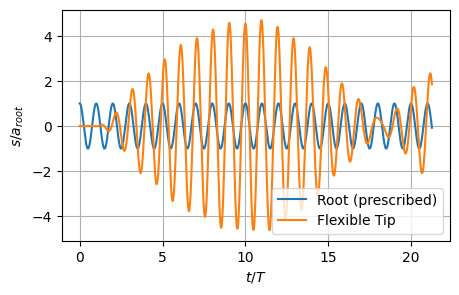

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(time_nd, root_nd, label="Root (prescribed)")
ax.plot(time_nd, tip_nd, label="Flexible Tip")
ax.set_xlabel(r"$t/T$")
ax.set_ylabel(r"$s/a_{root}$")
ax.grid(True)
ax.legend()
fig.savefig(FIG_DIR / "validation_tip_displacement.pdf")
plt.show()

In [7]:
Aroot = (root_disp.max() - root_disp.min()) / 2
Atip = (tip_w.max() - tip_w.min()) / 2
amp_ratio = Atip / Aroot
print("Tip amplification ratio =", amp_ratio)

Tip amplification ratio = 4.653598319566294


In [8]:
analytic_root = hilbert(root_disp)
analytic_tip  = hilbert(tip_w)
phase_root = np.unwrap(np.angle(analytic_root))
phase_tip = np.unwrap(np.angle(analytic_tip))
phase_lag = np.mean(phase_tip - phase_root)
print("Mean phase lag [rad] =", phase_lag)
print("Mean phase lag [deg] =", np.degrees(phase_lag))

Mean phase lag [rad] = -6.233489967920264
Mean phase lag [deg] = -357.1526667989701


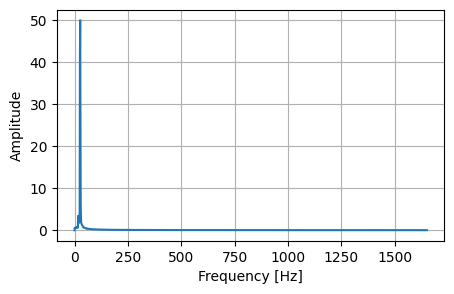

In [9]:
signal = tip_w - np.mean(tip_w)
fft_vals = np.fft.rfft(signal)
fft_freq = np.fft.rfftfreq(len(signal), d=dt)
fft_amp = np.abs(fft_vals)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(fft_freq, fft_amp)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude")
ax.grid(True)
fig.savefig(FIG_DIR / "fft_tip_response.pdf")
plt.show()

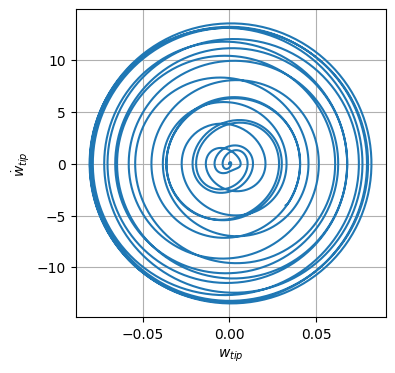

In [10]:
vel_tip = np.gradient(tip_w, dt)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(tip_w, vel_tip)
ax.set_xlabel(r"$w_{tip}$")
ax.set_ylabel(r"$\dot w_{tip}$")
ax.grid(True)
fig.savefig(FIG_DIR / "phase_space.pdf")
plt.show()

In [11]:
diag_path = SOLID_DIR / "solid_v18_diagnostics.csv"
if diag_path.exists():
    diag = pd.read_csv(diag_path)
    time_diag = diag["time"].values
    E_elas = diag["E_elas"].values
    E_kin  = diag["E_kin"].values
    E_damp = diag["E_damp"].values
    E_tot  = diag["E_tot"].values
    Wf = diag["work_Wf"].values
    Ws = diag["work_Ws"].values
    work_err = diag["work_rel_error"].values

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(time_diag, E_elas, label="Elastic")
    ax.plot(time_diag, E_kin, label="Kinetic")
    ax.plot(time_diag, E_damp, label="Damping")
    ax.plot(time_diag, E_tot, label="Total")
    ax.legend()
    ax.grid(True)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Energy")
    fig.savefig(FIG_DIR / "energy_history.pdf")
    plt.show()

    # Work error
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.semilogy(time_diag, np.abs(work_err))
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Relative Work Error")
    ax.grid(True)
    fig.savefig(FIG_DIR / "work_conservation_error.pdf")
    plt.show()

    # Statistics
    print("Mean work error =", np.mean(work_err))
    print("Max work error =", np.max(work_err))
    print("RMS work error =", np.sqrt(np.mean(work_err**2)))
else:
    print("Diagnostics file not found; skipping energy plots.")

Diagnostics file not found; skipping energy plots.


   step  n_forces  force_relax_used  force_residual     sample_fx  \
0     1        80               0.2        0.000000  0.000000e+00   
1     2        80               0.2        1.000000 -2.837801e-30   
2     3        80               0.2        1.000004  5.224211e-25   
3     4        80               0.2        0.965473  1.426335e-20   
4     5        80               0.2        0.927135  2.694361e-19   

      sample_fy     sample_fz  
0  0.000000e+00  0.000000e+00  
1  0.000000e+00  5.798805e-17  
2 -6.051757e-16 -1.989678e-11  
3 -9.004965e-15 -1.072437e-10  
4 -4.448381e-14 -3.217334e-10  


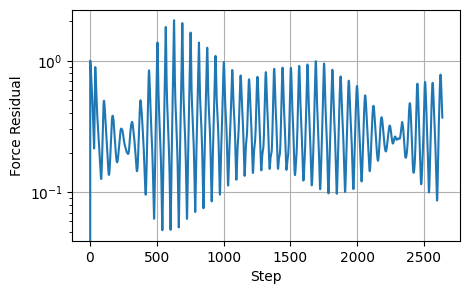

In [12]:
coupling_path = COUPLING_DIR / "coupling_history.csv"
if coupling_path.exists():
    coupling = pd.read_csv(coupling_path)
    print(coupling.head())
    # Plot force residual
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.semilogy(coupling["step"], coupling["force_residual"])
    ax.set_xlabel("Step")
    ax.set_ylabel("Force Residual")
    ax.grid(True)
    fig.savefig(FIG_DIR / "coupling_residual.pdf")
    plt.show()
else:
    print("Coupling history file not found.")

Skipping malformed line 2735: Expecting ',' delimiter: line 1 column 11022 (char 11021)


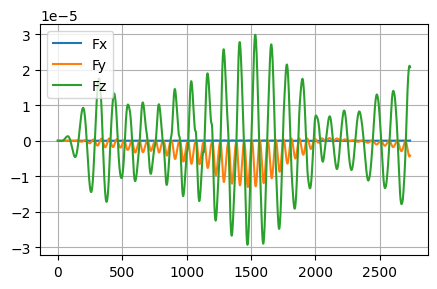

In [14]:
import json

json_file = COUPLING_DIR / "forces_sent_received_history.jsonl"
if json_file.exists():
    Fx, Fy, Fz, steps = [], [], [], []
    with open(json_file, "r") as fp:
        for line_num, line in enumerate(fp, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError as e:
                print(f"Skipping malformed line {line_num}: {e}")
                continue
            # Check if required keys exist
            if "force_sent" not in rec or not rec["force_sent"]:
                print(f"Skipping line {line_num}: missing 'force_sent'")
                continue
            f0 = rec["force_sent"][0]
            Fx.append(f0[0])
            Fy.append(f0[1])
            Fz.append(f0[2])
            steps.append(rec.get("step", line_num))
    
    if steps:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.plot(steps, Fx, label="Fx")
        ax.plot(steps, Fy, label="Fy")
        ax.plot(steps, Fz, label="Fz")
        ax.legend()
        ax.grid(True)
        fig.savefig(FIG_DIR / "force_history_cp0.pdf")
        plt.show()
    else:
        print("No valid data read from forces JSONL.")
else:
    print("Forces JSONL file not found.")